<a href="https://colab.research.google.com/github/mollyjenkin13/ucb_mids_s207_WildfirePrediction/blob/main/Wildfire_Prediction_Jordan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
from typing import Dict, List, Optional, Text, Tuple
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = '/content/drive/MyDrive/Wildfire Data/'
files = os.listdir(data_path)
print(f'Found {len(files)} files:')
for file in files:
  print(file)

Found 19 files:
next_day_wildfire_spread_eval_00.tfrecord
next_day_wildfire_spread_eval_01.tfrecord
next_day_wildfire_spread_test_00.tfrecord
next_day_wildfire_spread_test_01.tfrecord
next_day_wildfire_spread_train_00.tfrecord
next_day_wildfire_spread_train_01.tfrecord
next_day_wildfire_spread_train_02.tfrecord
next_day_wildfire_spread_train_03.tfrecord
next_day_wildfire_spread_train_04.tfrecord
next_day_wildfire_spread_train_05.tfrecord
next_day_wildfire_spread_train_06.tfrecord
next_day_wildfire_spread_train_07.tfrecord
next_day_wildfire_spread_train_08.tfrecord
next_day_wildfire_spread_train_09.tfrecord
next_day_wildfire_spread_train_10.tfrecord
next_day_wildfire_spread_train_11.tfrecord
next_day_wildfire_spread_train_12.tfrecord
next_day_wildfire_spread_train_13.tfrecord
next_day_wildfire_spread_train_14.tfrecord


In [4]:
sample_file = data_path + files[0]
raw_data = tf.data.TFRecordDataset(sample_file)
for raw_record in raw_data.take(1):
  example = tf.train.Example()
  example.ParseFromString(raw_record.numpy())
  print(list(example.features.feature.keys()))

['tmmn', 'NDVI', 'FireMask', 'population', 'elevation', 'vs', 'pdsi', 'pr', 'tmmx', 'sph', 'th', 'PrevFireMask', 'erc']


In [5]:
features = ['tmmn', 'NDVI', 'FireMask', 'population', 'elevation', 'vs', 'pdsi', 'pr', 'tmmx', 'sph', 'th', 'PrevFireMask', 'erc']
feature_description = {f: tf.io.FixedLenFeature([64*64], tf.float32) for f in features}

def parse_record(raw_record):
    parsed = tf.io.parse_single_example(raw_record, feature_description)
    # Reshape each feature to 64x64
    return {k: tf.reshape(v, [64, 64]) for k, v in parsed.items()}

# Load all 19 files
all_files = [data_path + f for f in files]
full_dataset = tf.data.TFRecordDataset(all_files).map(parse_record)

# Verify by looking at one sample
for sample in full_dataset.take(1):
    for key, value in sample.items():
        print(f"{key}: shape={value.shape}, min={tf.reduce_min(value):.2f}, max={tf.reduce_max(value):.2f}")

FireMask: shape=(64, 64), min=-1.00, max=0.00
NDVI: shape=(64, 64), min=-4315.00, max=7902.00
PrevFireMask: shape=(64, 64), min=-1.00, max=1.00
elevation: shape=(64, 64), min=74.00, max=155.00
erc: shape=(64, 64), min=13.51, max=22.51
pdsi: shape=(64, 64), min=2.14, max=3.88
population: shape=(64, 64), min=0.00, max=2167.71
pr: shape=(64, 64), min=2.40, max=7.13
sph: shape=(64, 64), min=0.01, max=0.01
th: shape=(64, 64), min=140.82, max=168.41
tmmn: shape=(64, 64), min=277.53, max=280.71
tmmx: shape=(64, 64), min=291.79, max=295.07
vs: shape=(64, 64), min=3.73, max=4.25


In [6]:
INPUT_FEATURES = [
    'tmmn', 'tmmx', 'th', 'vs', 'pr',
    'sph', 'pdsi', 'NDVI', 'erc', 'population',
    'elevation', 'PrevFireMask',
]
OUTPUT_FEATURE = 'FireMask'
ALL_FEATURES   = INPUT_FEATURES + [OUTPUT_FEATURE]
GRID_SIZE      = 64

In [7]:
# Describing the features
FEATURE_DESC = {
    feat: tf.io.FixedLenFeature([GRID_SIZE * GRID_SIZE], tf.float32)
    for feat in ALL_FEATURES
}

In [8]:
def load_split(data_dir, prefix):
    file_paths = sorted([
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith('.tfrecord') and prefix in f
    ])
    print(f"[{prefix}] found {len(file_paths)} files: {[os.path.basename(p) for p in file_paths]}")

    records = []
    for path in file_paths:
        for raw in tf.data.TFRecordDataset(path):
            parsed = tf.io.parse_single_example(raw, FEATURE_DESC)
            records.append({f: parsed[f].numpy() for f in ALL_FEATURES})
    return records

train_records = load_split(data_path, 'train')
val_records   = load_split(data_path, 'eval')
test_records  = load_split(data_path, 'test')

print(f"\nTrain : {len(train_records)}")
print(f"Val   : {len(val_records)}")
print(f"Test  : {len(test_records)}")

[train] found 15 files: ['next_day_wildfire_spread_train_00.tfrecord', 'next_day_wildfire_spread_train_01.tfrecord', 'next_day_wildfire_spread_train_02.tfrecord', 'next_day_wildfire_spread_train_03.tfrecord', 'next_day_wildfire_spread_train_04.tfrecord', 'next_day_wildfire_spread_train_05.tfrecord', 'next_day_wildfire_spread_train_06.tfrecord', 'next_day_wildfire_spread_train_07.tfrecord', 'next_day_wildfire_spread_train_08.tfrecord', 'next_day_wildfire_spread_train_09.tfrecord', 'next_day_wildfire_spread_train_10.tfrecord', 'next_day_wildfire_spread_train_11.tfrecord', 'next_day_wildfire_spread_train_12.tfrecord', 'next_day_wildfire_spread_train_13.tfrecord', 'next_day_wildfire_spread_train_14.tfrecord']
[eval] found 2 files: ['next_day_wildfire_spread_eval_00.tfrecord', 'next_day_wildfire_spread_eval_01.tfrecord']
[test] found 2 files: ['next_day_wildfire_spread_test_00.tfrecord', 'next_day_wildfire_spread_test_01.tfrecord']

Train : 14979
Val   : 1877
Test  : 1689


In [9]:
def records_to_XY(records):
    X = np.stack([
        np.stack([r[f].reshape(GRID_SIZE, GRID_SIZE) for f in INPUT_FEATURES], axis=-1)
        for r in records
    ])  # (N, 64, 64, 12)
    Y = np.stack([
        r[OUTPUT_FEATURE].reshape(GRID_SIZE, GRID_SIZE)
        for r in records
    ])  # (N, 64, 64)
    return X, Y

# Convert and immediately free each records list
train_records = load_split(data_path, 'train')
X_train, Y_train = records_to_XY(train_records)
del train_records

val_records = load_split(data_path, 'eval')
X_val, Y_val = records_to_XY(val_records)
del val_records

test_records = load_split(data_path, 'test')
X_test, Y_test = records_to_XY(test_records)
del test_records

import gc
gc.collect()

print(f"X_train : {X_train.shape}  Y_train : {Y_train.shape}")
print(f"X_val   : {X_val.shape}  Y_val   : {Y_val.shape}")
print(f"X_test  : {X_test.shape}  Y_test  : {Y_test.shape}")

[train] found 15 files: ['next_day_wildfire_spread_train_00.tfrecord', 'next_day_wildfire_spread_train_01.tfrecord', 'next_day_wildfire_spread_train_02.tfrecord', 'next_day_wildfire_spread_train_03.tfrecord', 'next_day_wildfire_spread_train_04.tfrecord', 'next_day_wildfire_spread_train_05.tfrecord', 'next_day_wildfire_spread_train_06.tfrecord', 'next_day_wildfire_spread_train_07.tfrecord', 'next_day_wildfire_spread_train_08.tfrecord', 'next_day_wildfire_spread_train_09.tfrecord', 'next_day_wildfire_spread_train_10.tfrecord', 'next_day_wildfire_spread_train_11.tfrecord', 'next_day_wildfire_spread_train_12.tfrecord', 'next_day_wildfire_spread_train_13.tfrecord', 'next_day_wildfire_spread_train_14.tfrecord']
[eval] found 2 files: ['next_day_wildfire_spread_eval_00.tfrecord', 'next_day_wildfire_spread_eval_01.tfrecord']
[test] found 2 files: ['next_day_wildfire_spread_test_00.tfrecord', 'next_day_wildfire_spread_test_01.tfrecord']
X_train : (14979, 64, 64, 12)  Y_train : (14979, 64, 64)
X_

In [10]:
# Each row = one sample; each column = spatial mean of that feature's 64×64 grid.
def XY_to_df(X, Y):
    df = pd.DataFrame(
        X.reshape(len(X), -1, X.shape[-1]).mean(axis=1),  # mean over 64×64 pixels
        columns=INPUT_FEATURES
    )
    df[OUTPUT_FEATURE]        = Y.reshape(len(Y), -1).mean(axis=1)
    df['fire_pixel_fraction'] = (Y.reshape(len(Y), -1) > 0).mean(axis=1)
    df['has_fire']            = (df['fire_pixel_fraction'] > 0).astype(int)
    return df

df_train = XY_to_df(X_train, Y_train)   # EDA runs on this only

In [11]:
df_train

,tmmn,tmmx,th,vs,pr,sph,pdsi,NDVI,erc,population,elevation,PrevFireMask,FireMask,fire_pixel_fraction,has_fire
0,275.737244,292.976379,174.233688,3.028635,0.000000e+00,0.004588,3.718297,7520.239258,20.463583,8.426229,85.027588,0.002686,0.001709,0.001709,1
1,276.452362,296.307617,293.806335,2.918970,0.000000e+00,0.005194,3.718297,7520.239258,23.228945,8.426229,85.027588,0.001221,0.000000,0.000000,0
2,294.328491,305.720764,80.196991,3.518154,-9.646169e-07,0.016385,-1.367441,8454.342773,20.090858,8.426229,85.027588,0.004150,0.001709,0.001709,1
3,285.614319,296.947784,268.047699,3.909244,8.020741e+00,0.009392,-1.944095,6057.897461,25.684225,18.248941,108.591553,0.000732,0.000000,0.000000,0
4,275.862030,293.866058,106.072205,4.179440,9.342304e-03,0.005647,4.597952,6653.061523,25.363012,18.248941,108.591553,0.001709,0.001221,0.001221,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14974,277.916626,292.084167,251.346649,3.956603,0.000000e+00,0.004444,0.247099,5478.994629,62.303246,0.009263,1903.739258,0.003906,-0.009033,0.000732,1
14975,286.082855,303.081390,252.162506,4.732237,4.738478e-01,0.010324,-4.515434,7443.789062,30.698494,4.213889,41.162842,0.001221,0.021240,0.021240,1
14976,288.767059,307.794952,275.822388,3.503413,0.000000e+00,0.003356,-1.545709,3888.437256,93.406021,0.378543,1411.199707,0.008545,0.010986,0.010986,1
14977,239.485779,248.702316,138.660797,2.456568,2.552041e+00,0.012501,2.412494,4383.423828,22.349335,106.774780,201.099609,-0.003418,-0.716553,0.000000,0


In [12]:
# Define the renaming dictionary
rename_dict = {
    'tmmn': 'min_temperature',
    'tmmx': 'max_temperature',
    'th': 'wind_direction',
    'vs': 'wind_velocity',
    'pr': 'precipitation',
    'sph': 'specific_humidity',
    'pdsi': 'drought_index',
    'NDVI': 'vegetation_index',
    'erc': 'energy_release_component',
    'population': 'population_density',
    'elevation': 'elevation',
    'PrevFireMask': 'previous_fire_mask',
    'FireMask': 'fire_mask'
}

# Rename the columns in place
df_train.rename(columns=rename_dict, inplace=True)

# Verify the changes
df_train.head()

,min_temperature,max_temperature,wind_direction,wind_velocity,precipitation,specific_humidity,drought_index,vegetation_index,energy_release_component,population_density,elevation,previous_fire_mask,fire_mask,fire_pixel_fraction,has_fire
0,275.737244,292.976379,174.233688,3.028635,0.000000e+00,0.004588,3.718297,7520.239258,20.463583,8.426229,85.027588,0.002686,0.001709,0.001709,1
1,276.452362,296.307617,293.806335,2.918970,0.000000e+00,0.005194,3.718297,7520.239258,23.228945,8.426229,85.027588,0.001221,0.000000,0.000000,0
2,294.328491,305.720764,80.196991,3.518154,-9.646169e-07,0.016385,-1.367441,8454.342773,20.090858,8.426229,85.027588,0.004150,0.001709,0.001709,1
3,285.614319,296.947784,268.047699,3.909244,8.020741e+00,0.009392,-1.944095,6057.897461,25.684225,18.248941,108.591553,0.000732,0.000000,0.000000,0
4,275.862030,293.866058,106.072205,4.179440,9.342304e-03,0.005647,4.597952,6653.061523,25.363012,18.248941,108.591553,0.001709,0.001221,0.001221,1


In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14979 entries, 0 to 14978
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   min_temperature           14979 non-null  float32
 1   max_temperature           14979 non-null  float32
 2   wind_direction            14979 non-null  float32
 3   wind_velocity             14979 non-null  float32
 4   precipitation             14979 non-null  float32
 5   specific_humidity         14979 non-null  float32
 6   drought_index             14979 non-null  float32
 7   vegetation_index          14979 non-null  float32
 8   energy_release_component  14979 non-null  float32
 9   population_density        14979 non-null  float32
 10  elevation                 14979 non-null  float32
 11  previous_fire_mask        14979 non-null  float32
 12  fire_mask                 14979 non-null  float32
 13  fire_pixel_fraction       14979 non-null  float64
 14  has_fi

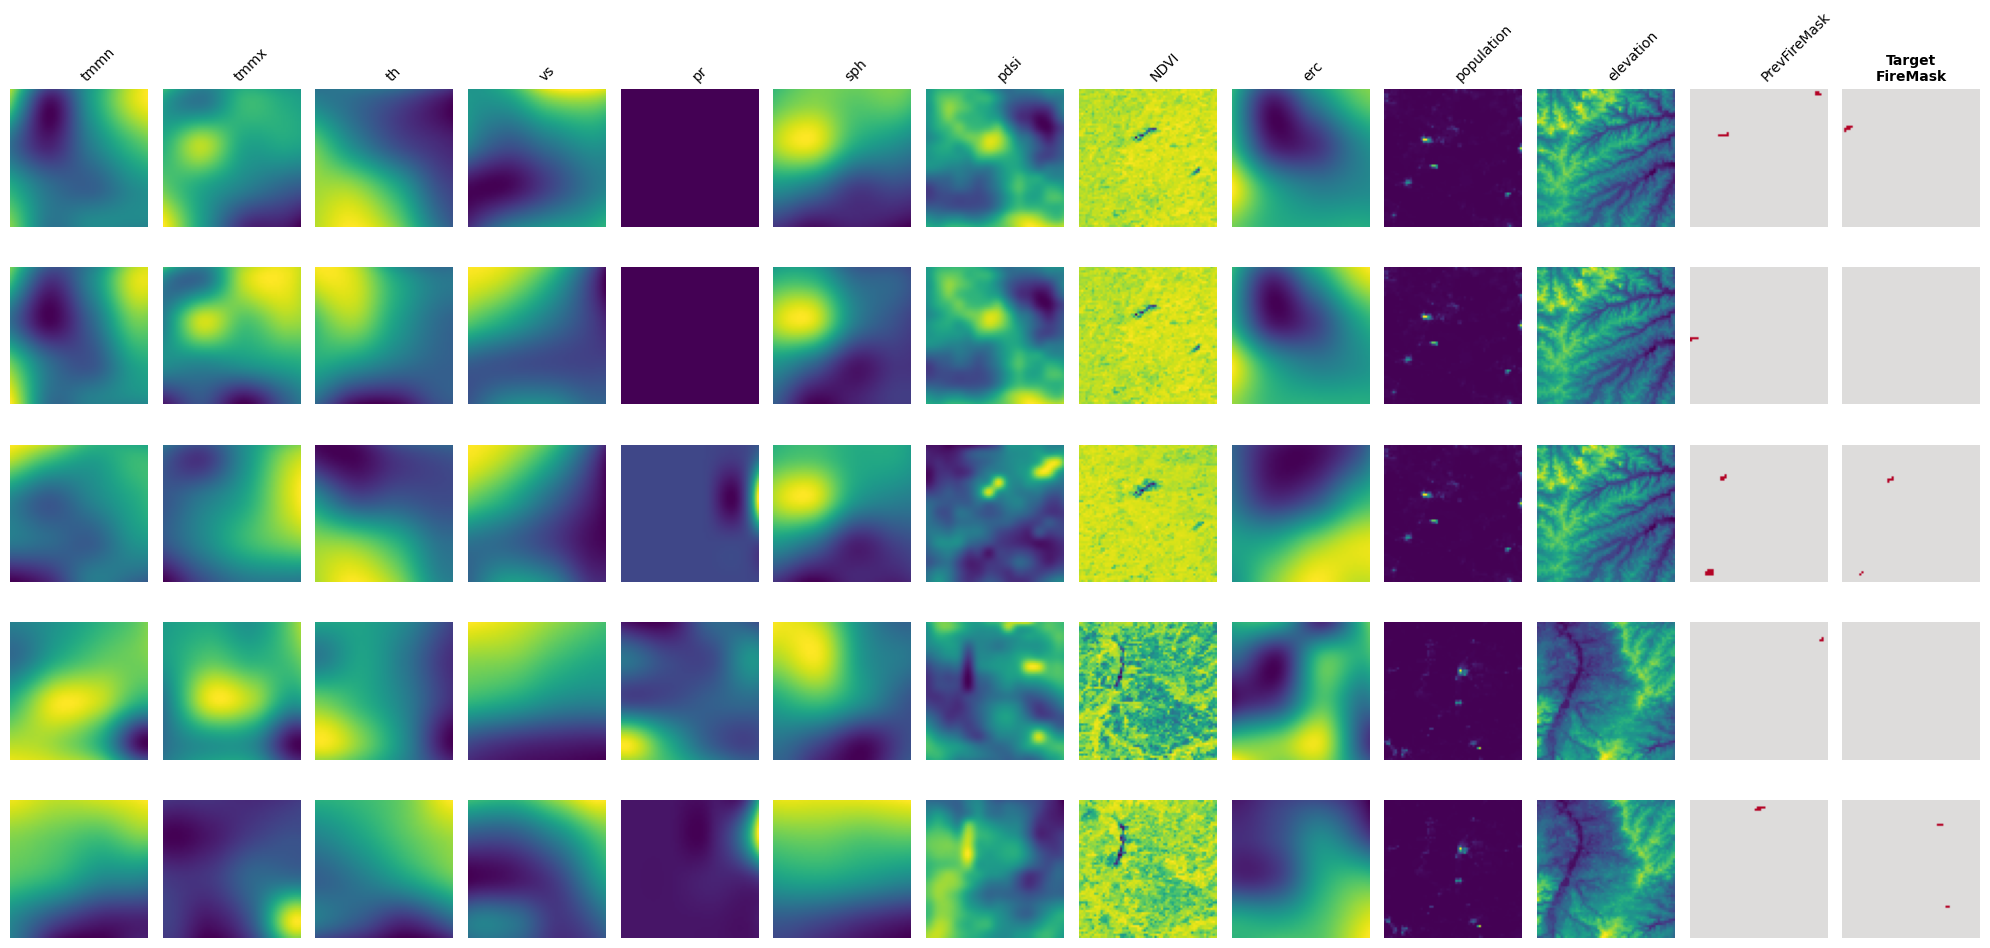

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Number of samples you want to display
n_samples = 5
n_features = len(INPUT_FEATURES)

# Create a grid of subplots: 5 rows (samples) x 13 columns (12 inputs + 1 target mask)
fig, axs = plt.subplots(nrows=n_samples, ncols=n_features + 1, figsize=(20, 10))

for i in range(n_samples):
    # --- 1. Plot the 12 Input Features ---
    for j, feature_name in enumerate(INPUT_FEATURES):
        ax = axs[i, j]
        # Grab the 64x64 slice for sample i, feature j
        pixel_grid = X_train[i, :, :, j]

        # Use viridis for environmental features, or specialized colormaps if preferred
        if feature_name in ['PrevFireMask', 'FireMask']:
            im = ax.imshow(pixel_grid, cmap='coolwarm', vmin=-1, vmax=1)
        else:
            im = ax.imshow(pixel_grid, cmap='viridis')

        ax.axis('off')

        # Only put titles on the very first row so it doesn't get cluttered
        if i == 0:
            ax.set_title(feature_name, fontsize=10, rotation=45, ha='left')

    # --- 2. Plot the Target Output Feature (FireMask) ---
    ax_target = axs[i, -1]
    target_grid = Y_train[i, :, :] # Y_train is shape (14979, 64, 64)

    ax_target.imshow(target_grid, cmap='coolwarm', vmin=-1, vmax=1)
    ax_target.axis('off')

    if i == 0:
        ax_target.set_title('Target\nFireMask', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

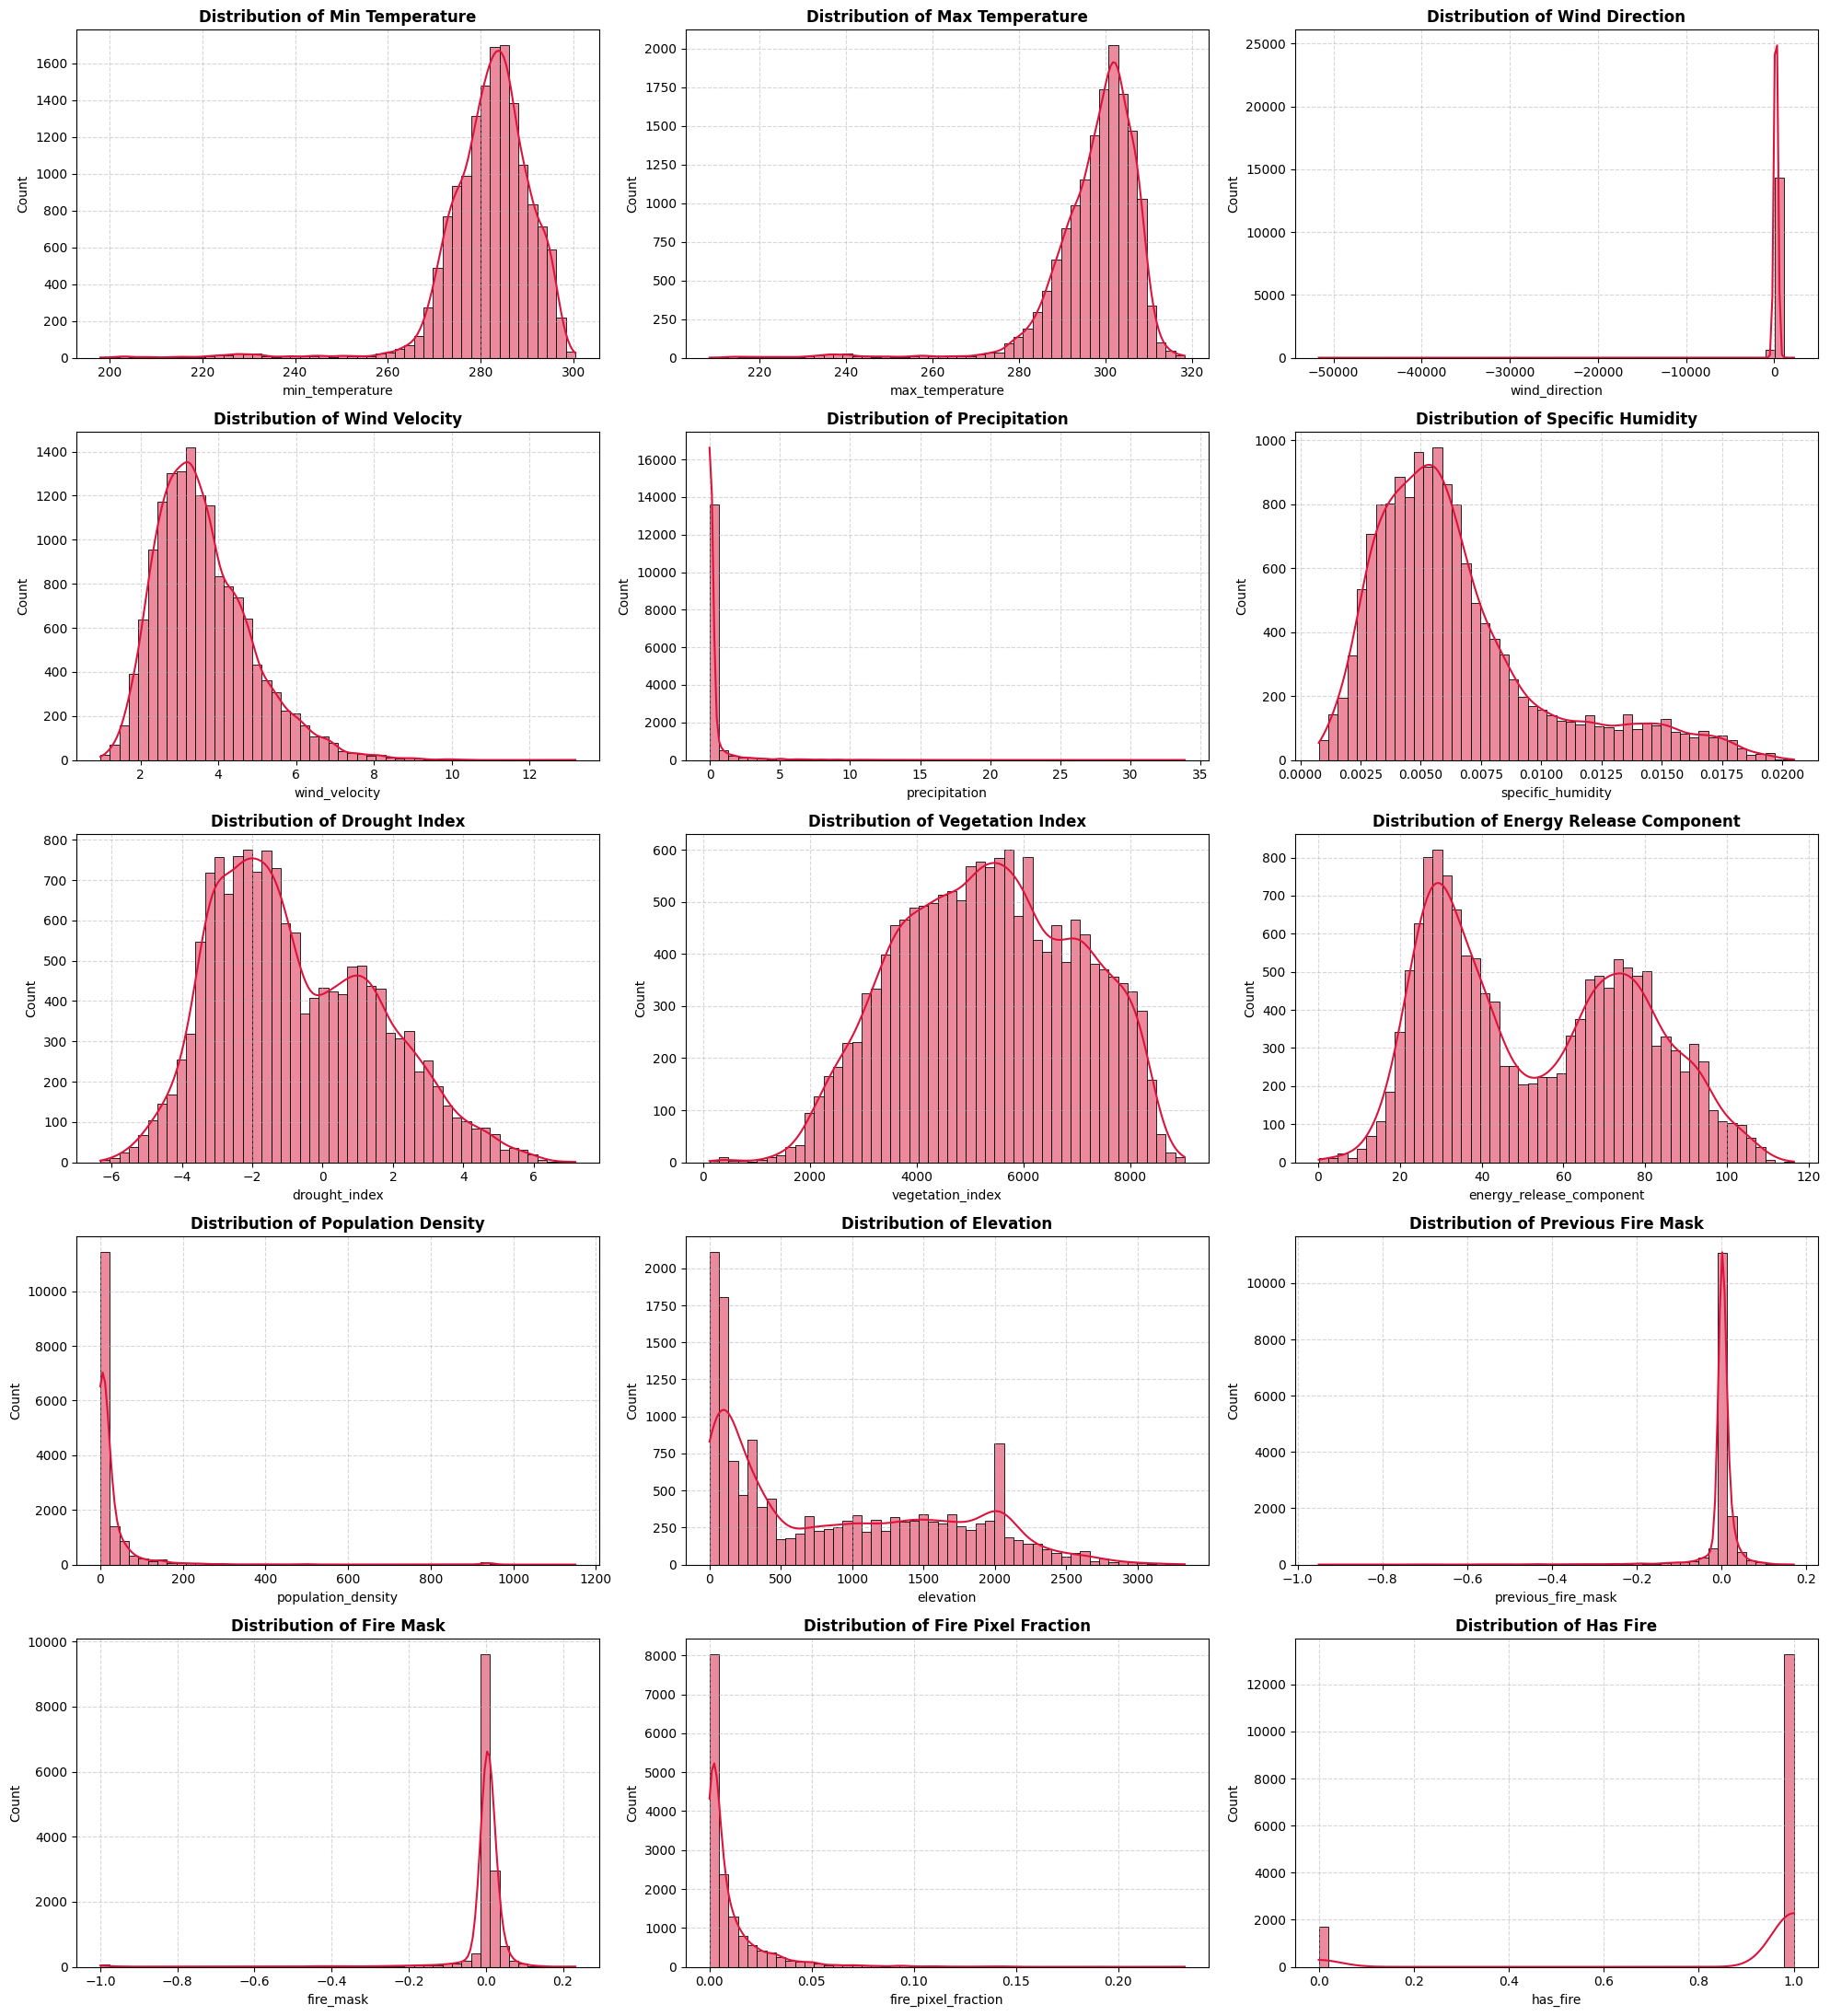

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set up a grid layout (5 rows x 3 columns = 15 total slots)
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 22))
axs = axs.flatten()  # Flatten the 2D grid array into a 1D list for easy looping

# 2. Loop through all columns in df_train
for i, col_name in enumerate(df_train.columns):
    # Plot the histogram on the current subplot axis
    sns.histplot(data=df_train, x=col_name, bins=50, kde=True, ax=axs[i], color='crimson')

    # Format titles and labels cleanly
    axs[i].set_title(f'Distribution of {col_name.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axs[i].set_xlabel(col_name)
    axs[i].set_ylabel('Count')
    axs[i].grid(True, linestyle='--', alpha=0.5)

# 3. Hide any leftover empty subplots (we have 15 slots but only 14 columns)
if len(axs) > len(df_train.columns):
    for j in range(len(df_train.columns), len(axs)):
        axs[j].axis('off')

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

In [16]:
for col in df_train.columns:
  print(f'Column: {col}')
  print(f'Minimum value: {df_train[col].min()}')
  print(f'Maximum value: {df_train[col].max()}')
  print(df_train[col].quantile([0.25, 0.5, 0.75]));

Column: min_temperature
Minimum value: 198.03306579589844
Maximum value: 300.3972473144531
0.25    277.414215
0.50    282.819427
0.75    287.588135
Name: min_temperature, dtype: float64
Column: max_temperature
Minimum value: 208.4518280029297
Maximum value: 318.1873779296875
0.25    293.603897
0.50    299.709564
0.75    303.928116
Name: max_temperature, dtype: float64
Column: wind_direction
Minimum value: -51674.703125
Maximum value: 2226.989501953125
0.25    152.115555
0.50    207.459244
0.75    252.161552
Name: wind_direction, dtype: float64
Column: wind_velocity
Minimum value: 0.9697684645652771
Maximum value: 13.17342472076416
0.25    2.747284
0.50    3.419904
0.75    4.327089
Name: wind_velocity, dtype: float64
Column: precipitation
Minimum value: -0.028327757492661476
Maximum value: 33.865478515625
0.25    0.000000
0.50    0.000000
0.75    0.021898
Name: precipitation, dtype: float64
Column: specific_humidity
Minimum value: 0.0007627710583619773
Maximum value: 0.02048580348491668

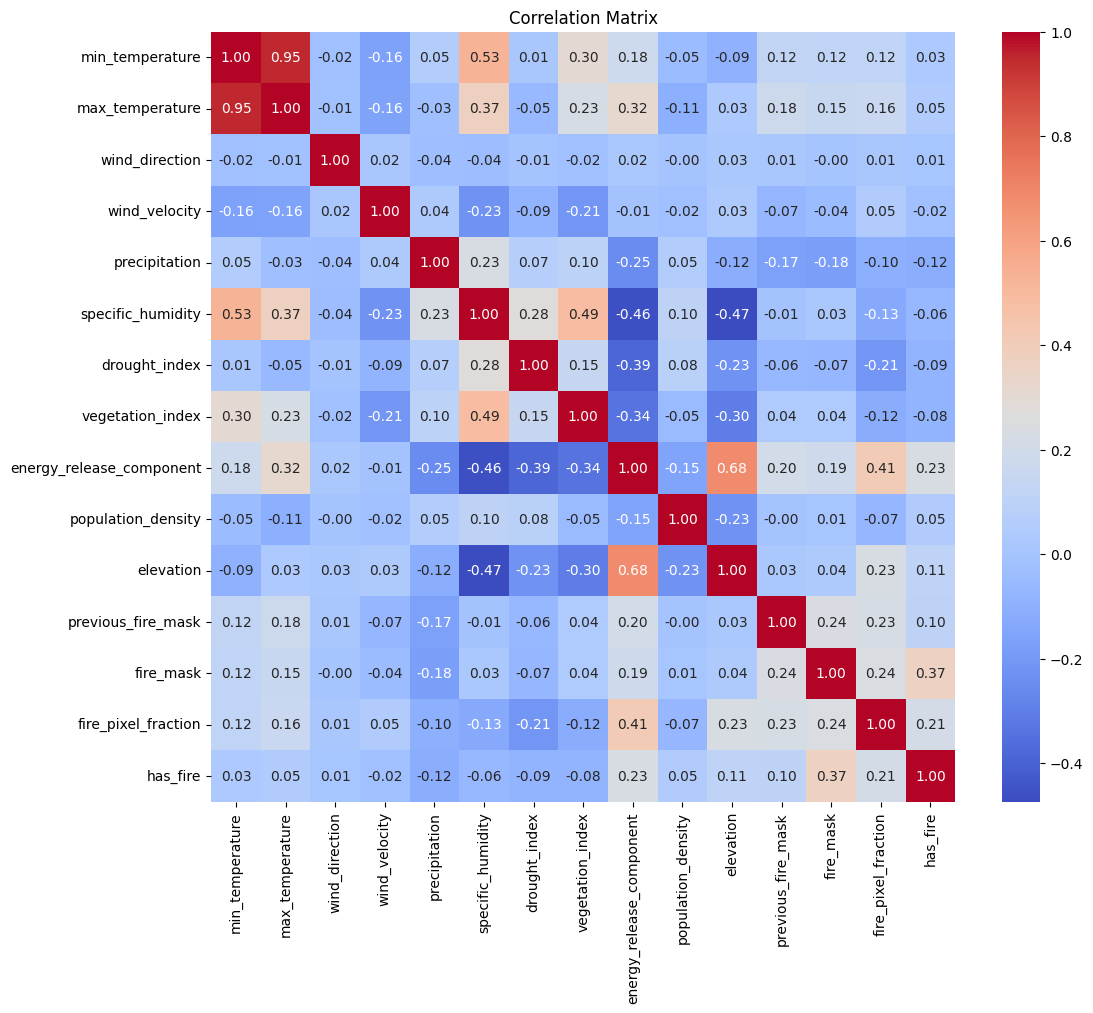

In [17]:
plt.figure(figsize=(12, 10))
corr_matrix = df_train.corr(method = 'pearson')
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()


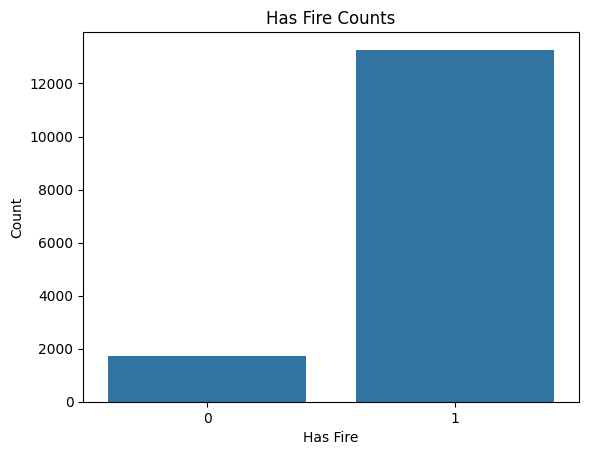

In [18]:
sns.countplot(data = df_train, x = 'has_fire')
plt.title('Has Fire Counts')
plt.xlabel('Has Fire')
plt.ylabel('Count')
plt.show()

In [19]:
df_train['has_fire'].value_counts()

,count
has_fire,
1,13273
0,1706


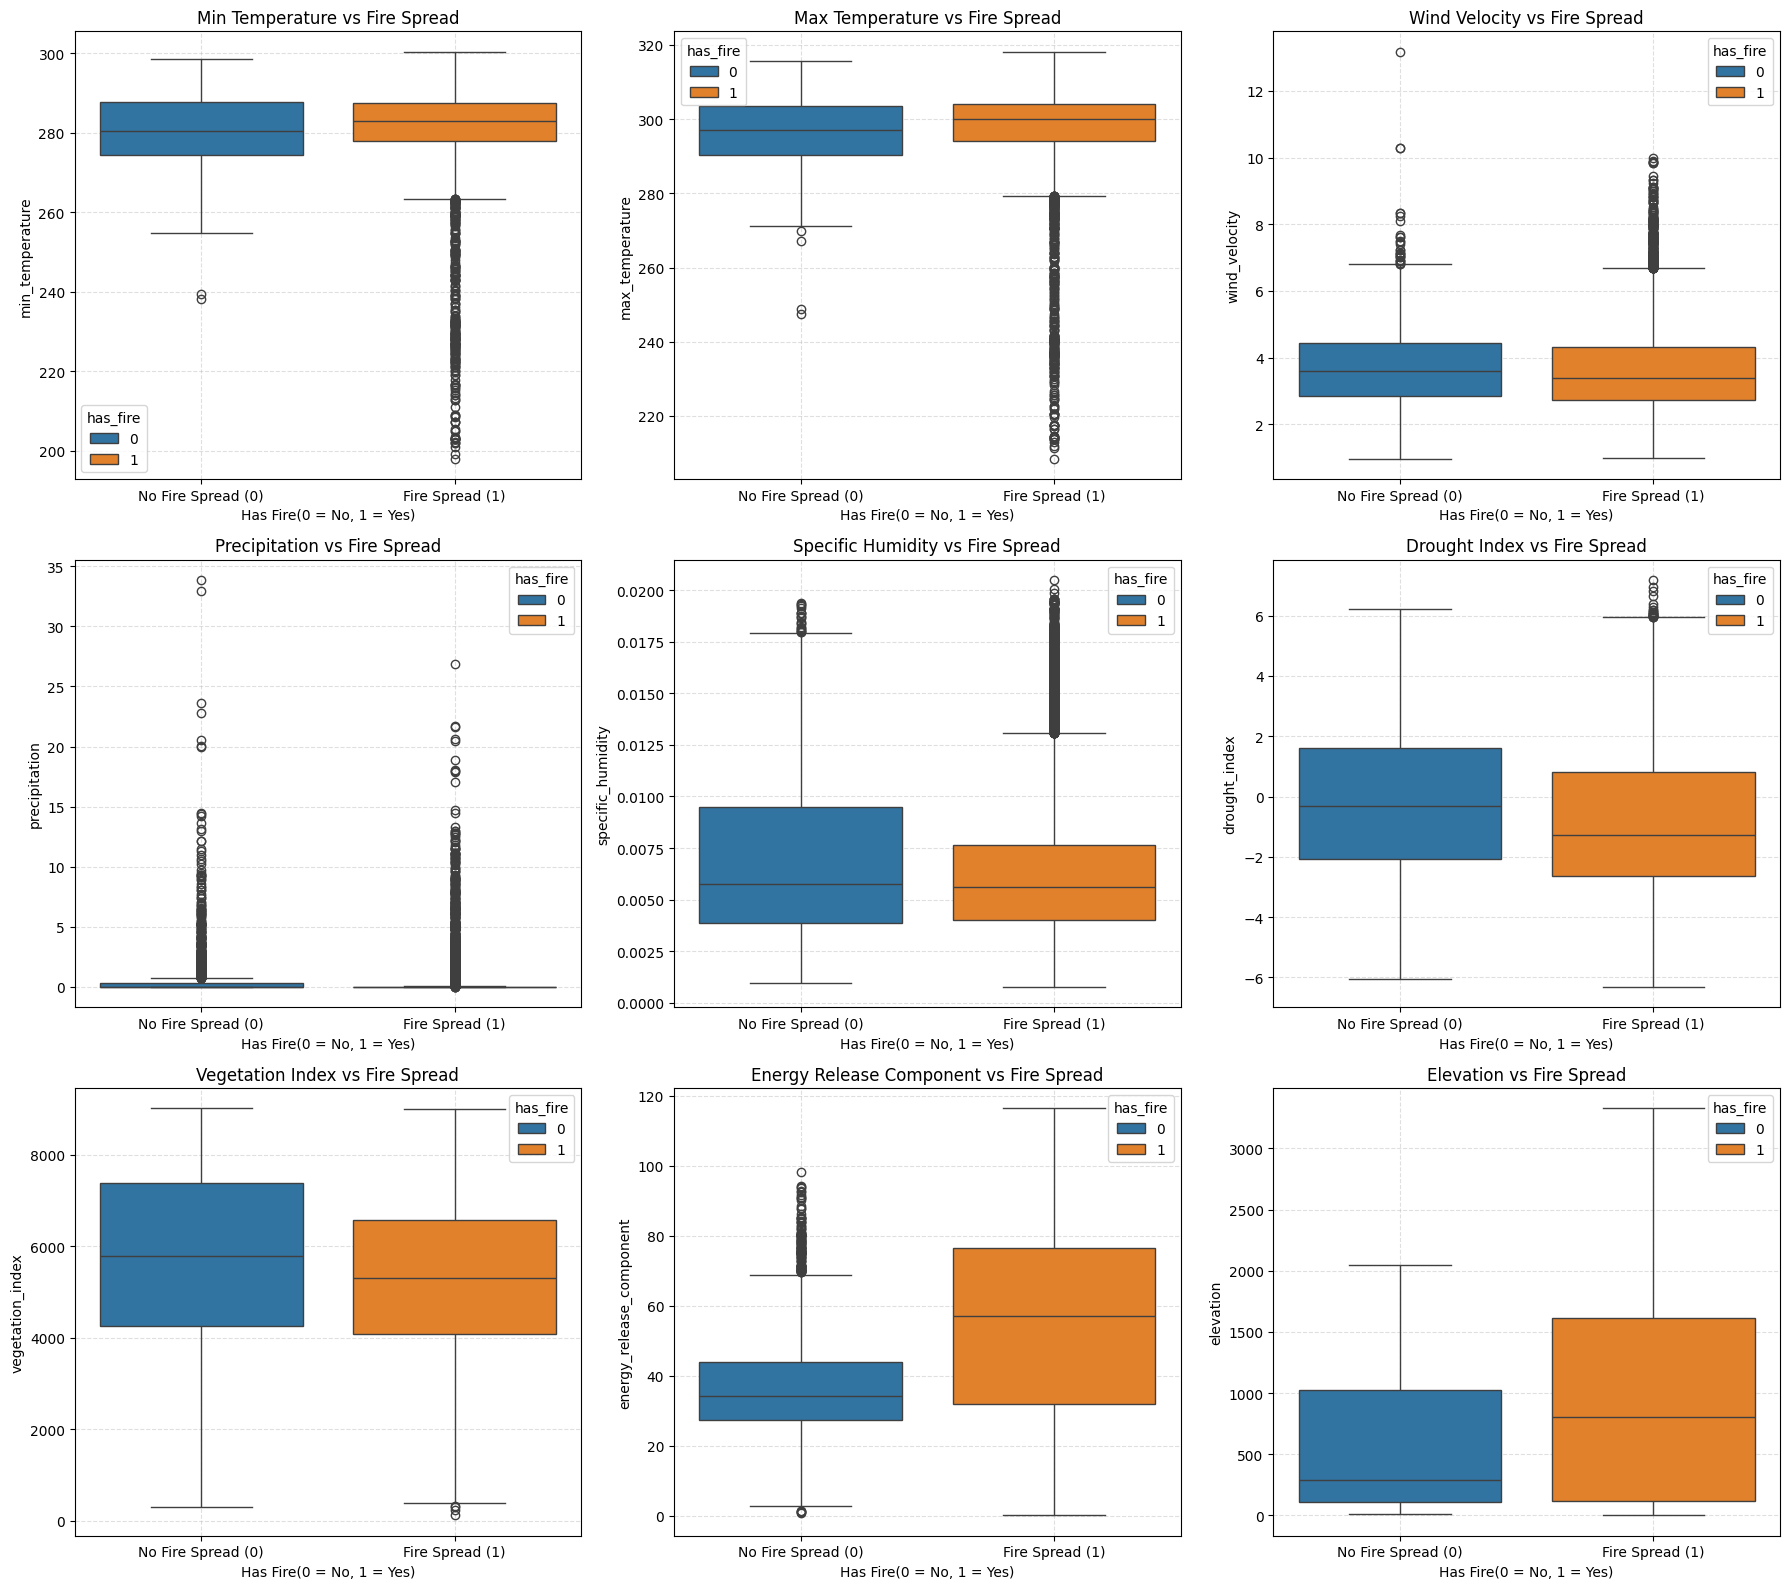

In [20]:
features_to_compare = [
    'min_temperature', 'max_temperature', 'wind_velocity',
    'precipitation', 'specific_humidity', 'drought_index',
    'vegetation_index', 'energy_release_component', 'elevation'
]
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18,16))
axs = axs.flatten()

for i, feature in enumerate(features_to_compare):
  sns.boxplot(data = df_train, x='has_fire', y=feature, ax=axs[i], hue='has_fire')

  title_name = feature.replace('_', ' ').title()
  axs[i].set_title(f'{title_name} vs Fire Spread')
  axs[i].set_xlabel('Has Fire(0 = No, 1 = Yes)')
  axs[i].set_ylabel(feature)

  axs[i].set_xticks([0, 1])
  axs[i].set_xticklabels(['No Fire Spread (0)', 'Fire Spread (1)'])

  axs[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


Preprocessing

In [21]:
#clip to 0
df_train['previous_fire_mask'] = df_train['previous_fire_mask'].clip(lower=0)
df_train['fire_mask'] = df_train['fire_mask'].clip(lower=0)
df_train['precipitation'] = df_train['precipitation'].clip(lower=0)
df_train['vegetation_index'] = df_train['vegetation_index'].clip(lower=0)
df_train.shape

(14979, 15)

In [22]:
#median imputations

#wind
valid_median = df_train.loc[(df_train['wind_direction'] >= 0) & (df_train['wind_direction'] <= 360),'wind_direction']
wind_median = valid_median.median()
df_train['wind_direction'] = df_train['wind_direction'].apply(lambda x: x if 0 <= x <= 360 else wind_median)

#temps
temp_median = df_train.loc[df_train['min_temperature'] > 240, 'min_temperature'].median()
df_train['min_temperature'] = df_train['min_temperature'].apply(lambda x: x if x>240 else temp_median)

In [23]:
#returning to true scale
df_train['vegetation_index'] = df_train['vegetation_index']/10000

In [24]:
#standardization
input_cols = [col for col in df_train.columns if col not in ['fire_mask', 'fire_pixel_fraction', 'has_fire']]

scaler = StandardScaler()
scaler.fit(df_train[input_cols])

def scale_spatial(x_array, fitted_scalar):
  N, H, W, C = x_array.shape

  x_flattened = x_array.reshape(-1, C)
  x_scaled_flattened = fitted_scalar.transform(x_flattened)
  x_scaled = x_scaled_flattened.reshape(N, H, W, C)
  return x_scaled

x_train_scaled = scale_spatial(X_train, scaler)
x_val_scaled = scale_spatial(X_val, scaler)
x_test_scaled = scale_spatial(X_test, scaler)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [25]:
x_train_scaled

array([[[[-8.19758594e-01, -4.41160053e-01, -4.07354444e-01, ...,
          -1.12934768e-01, -1.00740349e+00, -5.13141572e-01],
         [-8.27368379e-01, -4.43419844e-01, -4.08425927e-01, ...,
          -1.22111611e-01, -1.01992452e+00, -5.13141572e-01],
         [-8.35304141e-01, -4.45635915e-01, -4.09124583e-01, ...,
          -2.69469619e-01, -1.00990772e+00, -5.13141572e-01],
         ...,
         [-8.00136566e-01, -4.53196794e-01, -5.18139005e-01, ...,
          -3.93460654e-02, -1.02994132e+00, -5.13141572e-01],
         [-7.98643589e-01, -4.53532100e-01, -5.22748470e-01, ...,
          -2.96536207e-01, -1.03494966e+00, -5.13141572e-01],
         [-7.97279358e-01, -4.53864515e-01, -5.27451873e-01, ...,
          -3.05593550e-01, -1.03745389e+00, -5.13141572e-01]],

        [[-8.23026240e-01, -4.44029272e-01, -4.02921796e-01, ...,
          -1.39400899e-01, -1.00114298e+00, -5.13141572e-01],
         [-8.30829203e-01, -4.46268648e-01, -4.04462039e-01, ...,
          -5.13258018e

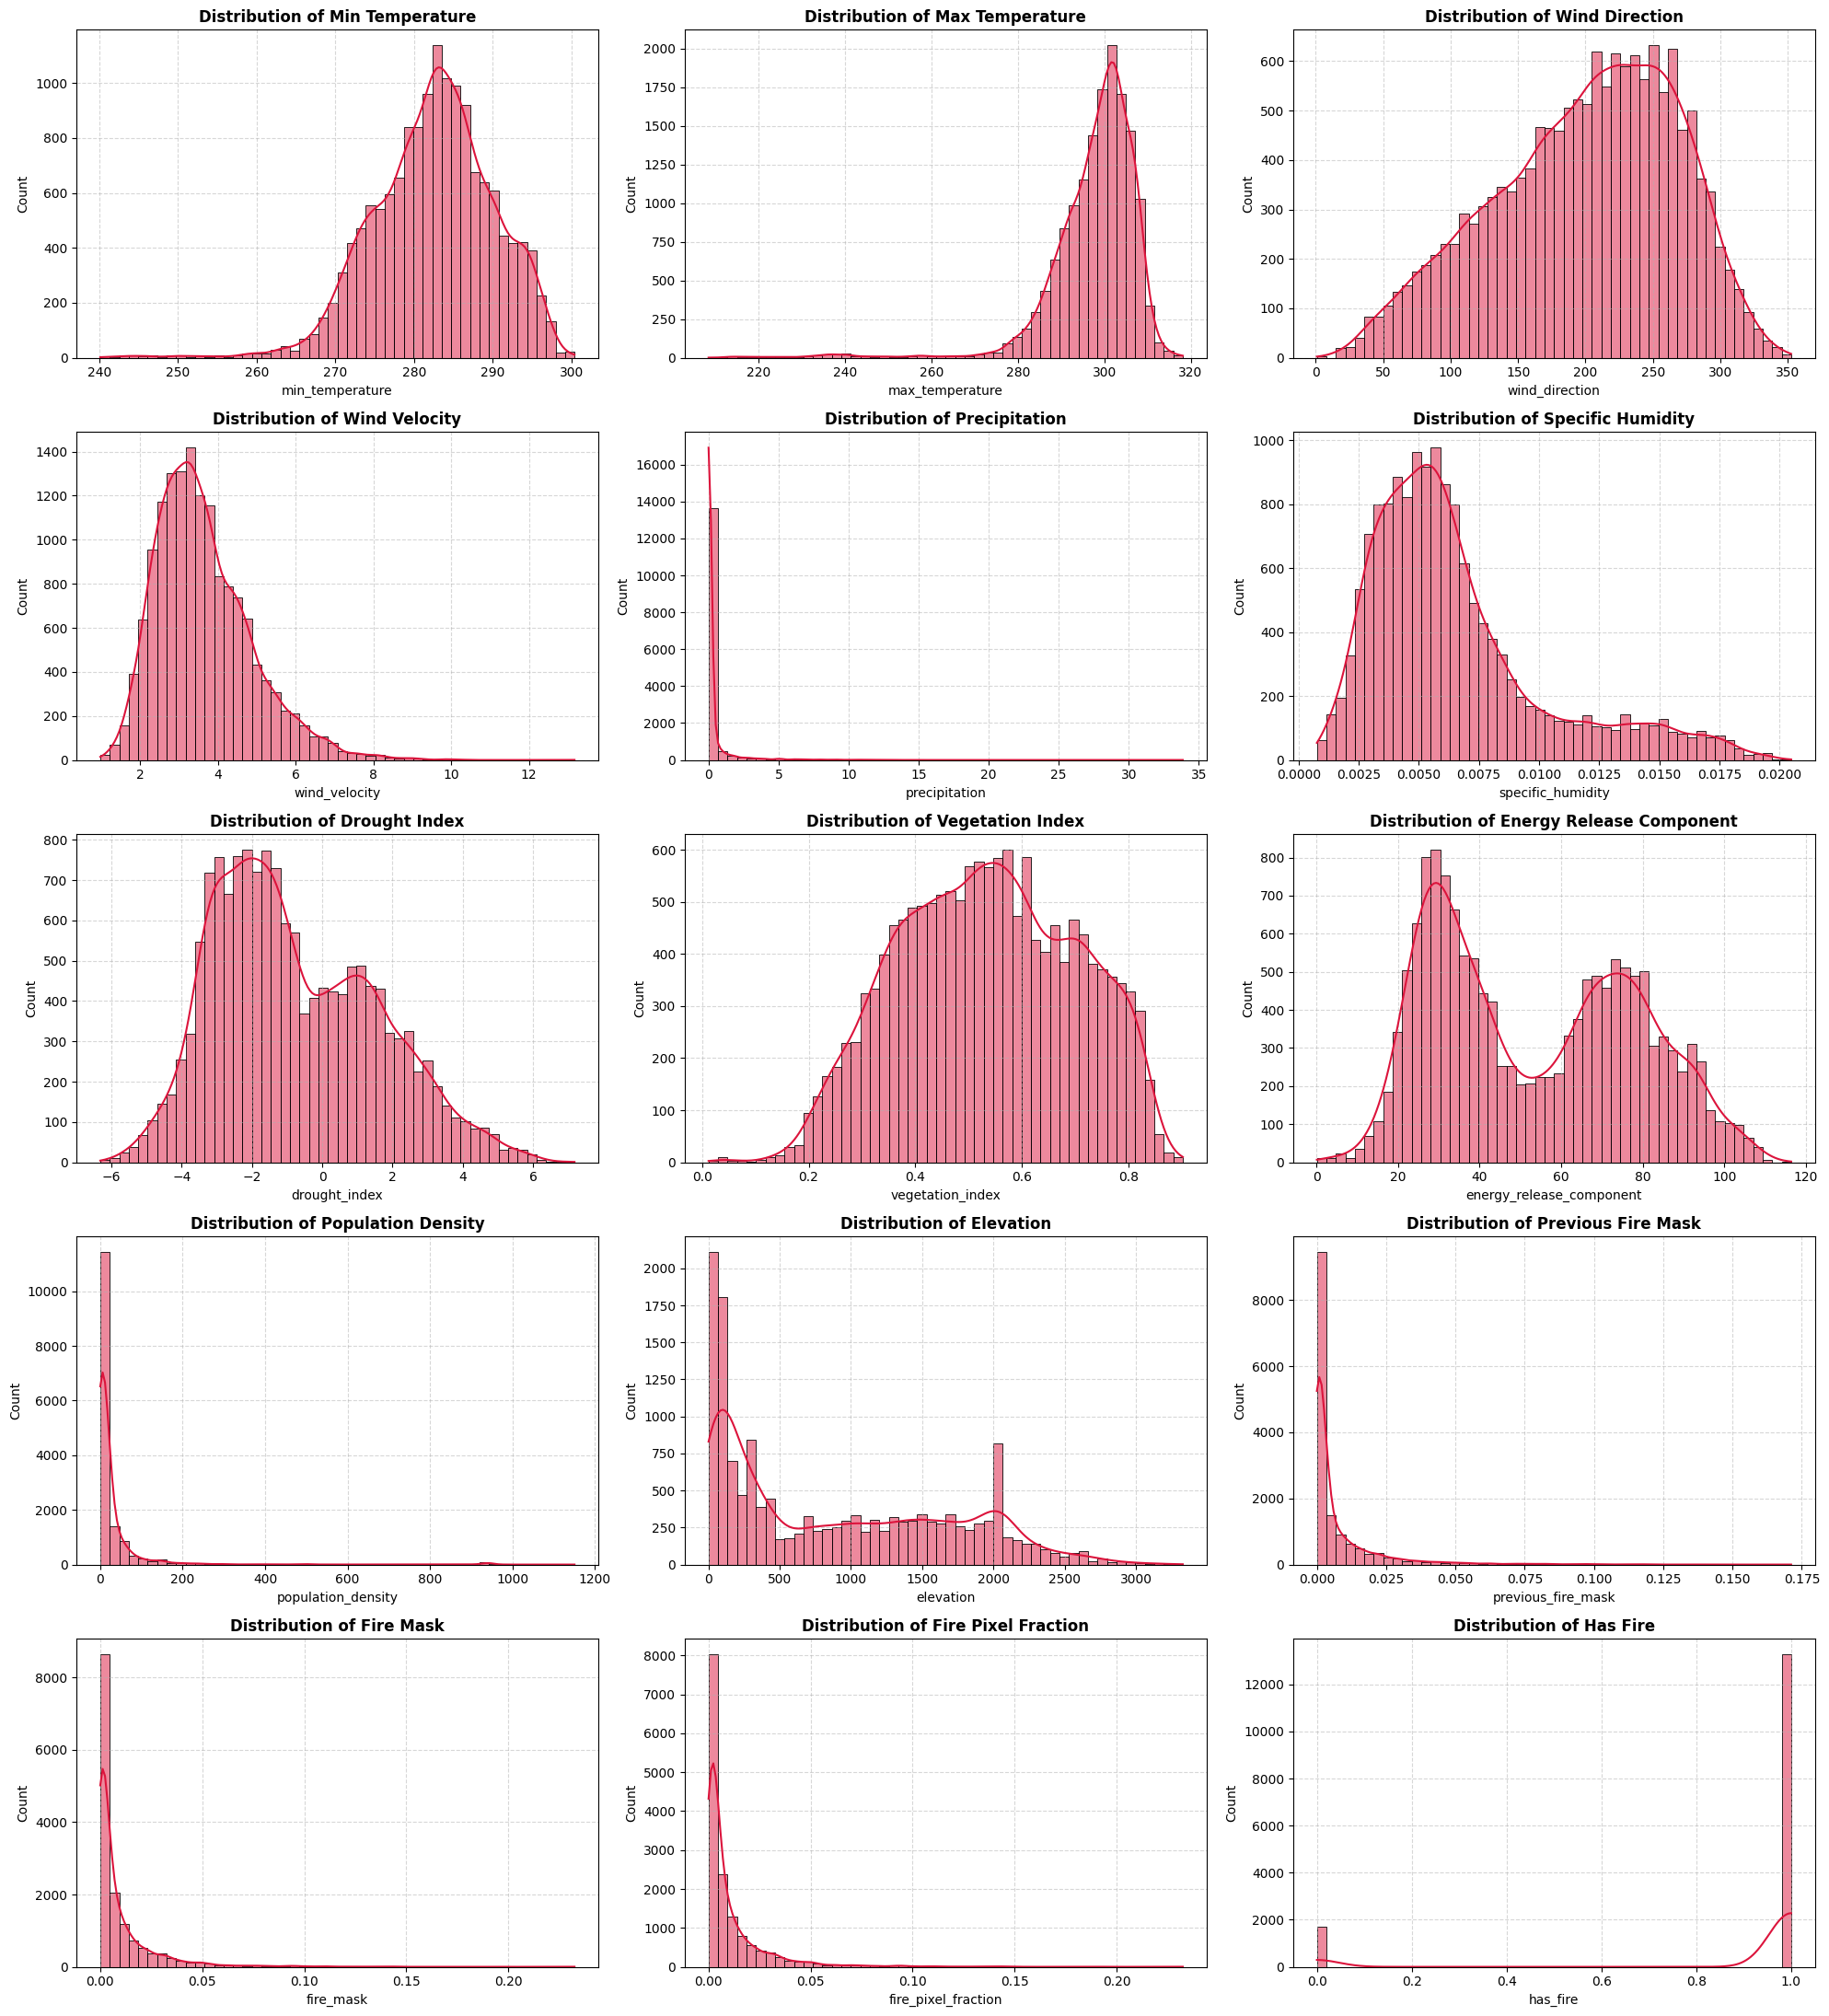

In [26]:
# 1. Set up a grid layout (5 rows x 3 columns = 15 total slots)
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 22))
axs = axs.flatten()  # Flatten the 2D grid array into a 1D list for easy looping

# 2. Loop through all columns in df_train
for i, col_name in enumerate(df_train.columns):
    # Plot the histogram on the current subplot axis
    sns.histplot(data=df_train, x=col_name, bins=50, kde=True, ax=axs[i], color='crimson')

    # Format titles and labels cleanly
    axs[i].set_title(f'Distribution of {col_name.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axs[i].set_xlabel(col_name)
    axs[i].set_ylabel('Count')
    axs[i].grid(True, linestyle='--', alpha=0.5)

# 3. Hide any leftover empty subplots (we have 15 slots but only 14 columns)
if len(axs) > len(df_train.columns):
    for j in range(len(df_train.columns), len(axs)):
        axs[j].axis('off')

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

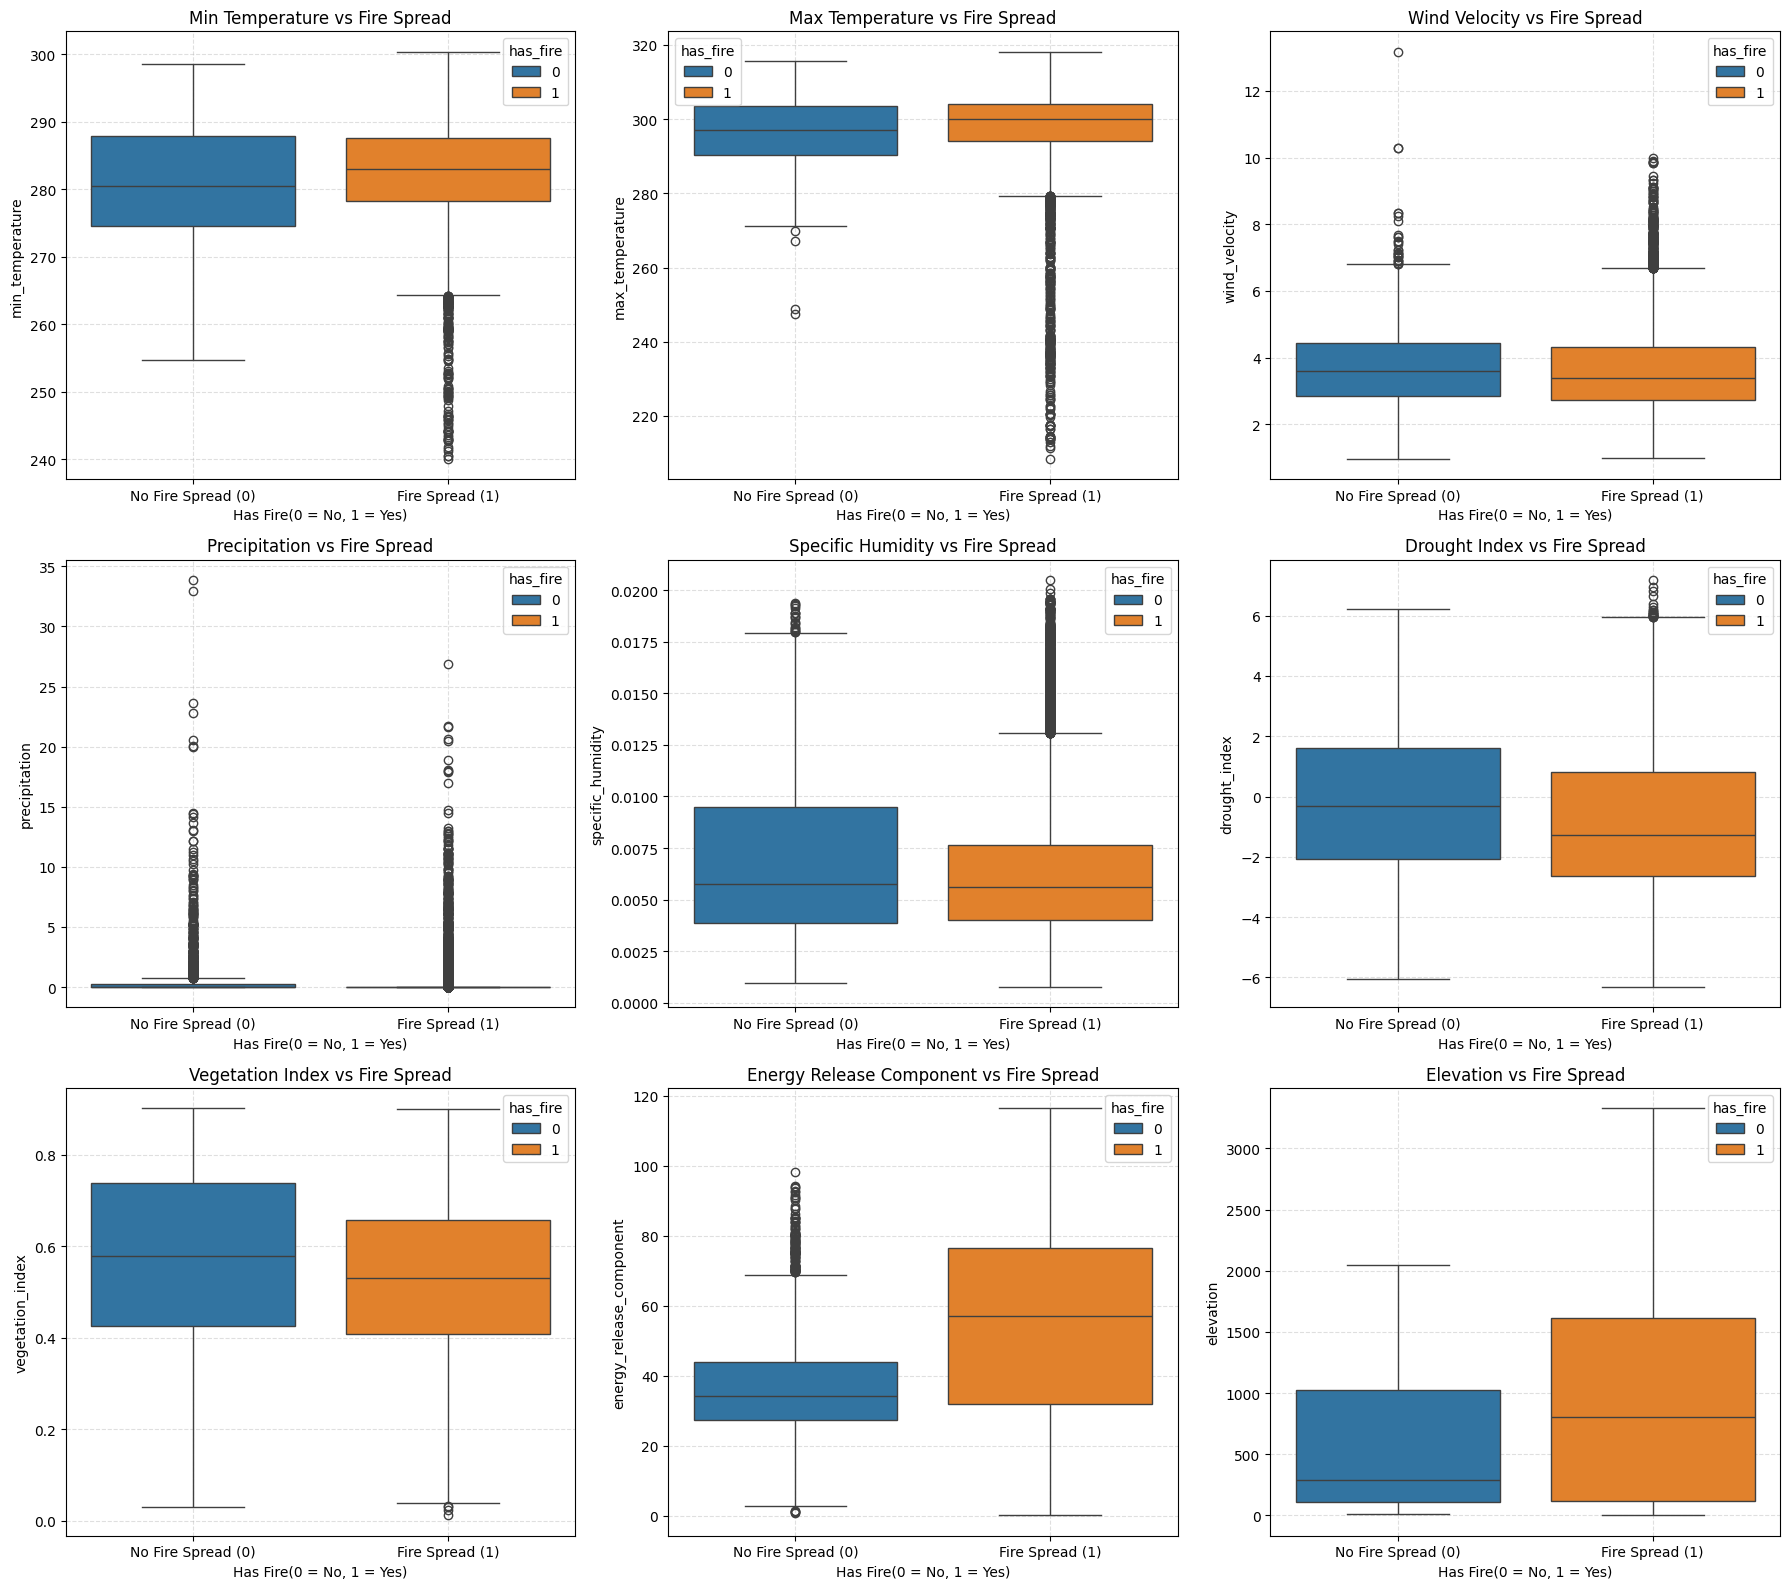

In [27]:
features_to_compare = [
    'min_temperature', 'max_temperature', 'wind_velocity',
    'precipitation', 'specific_humidity', 'drought_index',
    'vegetation_index', 'energy_release_component', 'elevation'
]
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18,16))
axs = axs.flatten()

for i, feature in enumerate(features_to_compare):
  sns.boxplot(data = df_train, x='has_fire', y=feature, ax=axs[i], hue='has_fire')

  title_name = feature.replace('_', ' ').title()
  axs[i].set_title(f'{title_name} vs Fire Spread')
  axs[i].set_xlabel('Has Fire(0 = No, 1 = Yes)')
  axs[i].set_ylabel(feature)

  axs[i].set_xticks([0, 1])
  axs[i].set_xticklabels(['No Fire Spread (0)', 'Fire Spread (1)'])

  axs[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
